## pinn_v5.ipynb 

### Changes from v3:
## 1. Imports and device setup

In [ ]:
import os, io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import torch
import torch.nn as nn

# float64 is mandatory: we compute 4th-order spatial derivatives via autograd.
# float32 accumulates too much rounding error at each grad() call.
DTYPE  = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, " | dtype:", DTYPE)

from google.colab import files
torch.manual_seed(42)
np.random.seed(42)

# ── Checkpoint setup ─────────────────────────────────────────────────────────
# Saves training state to Google Drive so that if Colab disconnects mid-training,
# you can rerun the notebook and it picks up from the last checkpoint automatically.
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/pinn_v4_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CKPT_ADAM  = os.path.join(CHECKPOINT_DIR, "adam_checkpoint.pt")
CKPT_LBFGS = os.path.join(CHECKPOINT_DIR, "lbfgs_checkpoint.pt")
CKPT_DONE  = os.path.join(CHECKPOINT_DIR, "training_complete.pt")

# How often to save (every N epochs/steps).
# Each save takes ~1-2s, so 1000 epochs = ~20 saves over 20k epochs — negligible overhead.
ADAM_CKPT_EVERY  = 1000
LBFGS_CKPT_EVERY = 30


def save_adam_checkpoint(epoch, w_net, e_net, physical_params, optimizer, scheduler, history):
    """Save full Adam training state to Drive."""
    torch.save({
        "epoch":       epoch,
        "w_net":       w_net.state_dict(),
        "e_net":       e_net.state_dict(),
        "phys":        {k: v.detach().clone() for k, v in physical_params.items()},
        "optimizer":   optimizer.state_dict(),
        "scheduler":   scheduler.state_dict(),
        "history":     history,
    }, CKPT_ADAM)


def load_adam_checkpoint(w_net, e_net, physical_params, optimizer, scheduler):
    """Resume Adam from checkpoint. Returns (start_epoch, history) or (0, fresh_history)."""
    if not os.path.exists(CKPT_ADAM):
        return 0, None
    ckpt = torch.load(CKPT_ADAM, map_location=device, weights_only=False)
    w_net.load_state_dict(ckpt["w_net"])
    e_net.load_state_dict(ckpt["e_net"])
    for k, v in ckpt["phys"].items():
        physical_params[k].data.copy_(v)
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start = ckpt["epoch"] + 1
    print(f"\u2713 Resumed Adam from epoch {start}")
    return start, ckpt["history"]


def save_lbfgs_checkpoint(step, w_net, e_net, physical_params, opt_lbfgs):
    """Save L-BFGS state to Drive."""
    torch.save({
        "step":  step,
        "w_net": w_net.state_dict(),
        "e_net": e_net.state_dict(),
        "phys":  {k: v.detach().clone() for k, v in physical_params.items()},
        "optimizer": opt_lbfgs.state_dict(),
    }, CKPT_LBFGS)


def load_lbfgs_checkpoint(w_net, e_net, physical_params, opt_lbfgs):
    """Resume L-BFGS from checkpoint. Returns start_step or 0."""
    if not os.path.exists(CKPT_LBFGS):
        return 0
    ckpt = torch.load(CKPT_LBFGS, map_location=device, weights_only=False)
    w_net.load_state_dict(ckpt["w_net"])
    e_net.load_state_dict(ckpt["e_net"])
    for k, v in ckpt["phys"].items():
        physical_params[k].data.copy_(v)
    opt_lbfgs.load_state_dict(ckpt["optimizer"])
    start = ckpt["step"] + 1
    print(f"\u2713 Resumed L-BFGS from step {start}")
    return start

Device: cuda  | dtype: torch.float64
Mounted at /content/drive


## 2. Beam geometry and experiment settings

**Boundary conditions agreed with supervisor:**
- `x = 0` → **fixed / clamped** end (with spring compliance kx, kphi to model imperfect clamping)
- `x = L` → **free** end with known tip mass `m_tip` and unknown tip force `F`

**What each unknown means:**
- `E(x)` — spatially varying Young's modulus [Pa]. Varies along beam length, e.g. due to non-uniform material or damage.
- `eta` — loss factor (hysteretic damping). Enters as complex modulus E*(x) = E(x)(1 + j·eta). Controls peak sharpness in FRF.
- `kx` — translational spring stiffness at clamped end [N/m]. Models fixture compliance in lateral direction. kx→∞ = perfect rigid clamp.
- `kphi` — rotational spring stiffness at clamped end [N·m/rad]. Models fixture compliance in rotation. kphi→∞ = perfect rigid clamp.
- `F` — unknown tip force amplitude [N]. The velocity of excitation is known but the actual force at the tip is not.


In [ ]:
# ── Beam geometry (fixed, known from measurement) ────────────────────────────
L          = 126.06e-3   # beam length [m]
width      = 10.13e-3    # width [m]
height     = 0.95e-3     # thickness [m]
rho        = 8216.0      # density [kg/m^3]
bending_axis = "weak"
x_meas     = L           # FRF measured at tip (free end)
m_tip      = 10e-3       # tip mass [kg]

# ── Frequency range ───────────────────────────────────────────────────────────
# Only keep data where Euler-Bernoulli is valid and SNR is good.
# From your experimental plot: useful signal up to ~5000 Hz.
MIN_FREQ_HZ = 1.0        # avoid singular matrix at 0 Hz
MAX_FREQ_HZ = 5000.0     # hard cutoff

# ── Initial guesses for scalar unknowns ──────────────────────────────────────
# Adjust E0_init to your beam material:
#   Steel     ~ 200e9 Pa
#   Aluminium ~  70e9 Pa
#   Brass     ~ 100e9 Pa
E0_init    = 200e9       # [Pa]  initial guess for E(x) mean level
eta_init   = 0.01        # [-]   loss factor
kx_init    = 1e5         # [N/m] translational spring at x=0
kphi_init  = 1e3         # [N·m/rad] rotational spring at x=0
F_init     = 0.1         # [N]   tip force amplitude

# ── Derived geometry ──────────────────────────────────────────────────────────
A = width * height
if bending_axis.lower() == "weak":
    I = width * height**3 / 12.0
else:
    I = height * width**3  / 12.0

plot_in_db = True
eps_db     = 1e-16

print(f"L={L:.4f} m  width={width:.5f} m  height={height:.5f} m")
print(f"A={A:.4e} m^2   I={I:.4e} m^4")
print(f"Frequency range: {MIN_FREQ_HZ} – {MAX_FREQ_HZ} Hz")


L=0.1261 m  width=0.01013 m  height=0.00095 m
A=9.6235e-06 m^2   I=7.2377e-13 m^4
Frequency range: 1.0 – 5000.0 Hz


## 3. Upload and load experimental FRF

Upload your `.npy` or `.npz` file. The loader handles common key naming conventions,
removes invalid entries, and sorts by frequency.


In [ ]:
def _pick(d, keys):
    for k in keys:
        if k in d: return k
    return None

def load_frf(path, x_meas):
    ext  = os.path.splitext(path)[1].lower()
    fk   = ["freq","f","frequency","f_hz","freq_s1"]
    vrfk = ["frf","V","velocity","response","H","s1_fft"]

    if ext == ".npz":
        data = np.load(path, allow_pickle=True)
        print("NPZ keys:", list(data.keys()))
        fkey = _pick(data, fk); vkey = _pick(data, vrfk)
        if fkey and vkey:
            f = data[fkey].reshape(-1).astype(float)
            V = data[vkey].reshape(-1)
        else:
            raise ValueError(f"Cannot find freq/FRF keys in {list(data.keys())}")

    elif ext == ".npy":
        arr  = np.load(path, allow_pickle=True)
        data = arr.item() if hasattr(arr, "item") else None
        if not isinstance(data, dict):
            raise ValueError("Plain .npy unsupported — use .npz")
        print("NPY keys:", list(data.keys()))
        fkey = _pick(data, fk); vkey = _pick(data, vrfk)
        if fkey and vkey:
            f = data[fkey].reshape(-1).astype(float)
            V = data[vkey].reshape(-1)
        else:
            raise ValueError(f"Cannot find freq/FRF keys in {list(data.keys())}")
    else:
        raise ValueError("Only .npy / .npz supported")

    if not np.iscomplexobj(V):
        raise ValueError("FRF array must be complex (real + imag parts)")

    # Clean up
    mask = np.isfinite(f) & np.isfinite(V.real) & np.isfinite(V.imag) & (f >= 0)
    f, V = f[mask], V[mask]
    order = np.argsort(f)
    f, V  = f[order], V[order]

    # Average duplicate frequencies
    df = pd.DataFrame({"f":f,"Vr":V.real,"Vi":V.imag}).groupby("f",as_index=False).mean()
    f  = df["f"].to_numpy()
    V  = df["Vr"].to_numpy() + 1j*df["Vi"].to_numpy()
    x  = np.full_like(f, x_meas)
    return f, x, V

uploaded      = files.upload()
uploaded_name = list(uploaded.keys())[0]
print("Uploaded:", uploaded_name)


Saving Output.npy to Output.npy
Uploaded: Output.npy


## 3.1 code to view the values in the `.npy` file

In [ ]:
# ── Inspect the uploaded file ─────────────────────────────────────────────────
ext = os.path.splitext(uploaded_name)[1].lower()
print(f"File: {uploaded_name}  ({ext})")

if ext == ".npz":
    raw = np.load(uploaded_name, allow_pickle=True)
    print(f"NPZ keys: {list(raw.keys())}")
    data_dict = {k: raw[k] for k in raw.keys()}
elif ext == ".npy":
    arr = np.load(uploaded_name, allow_pickle=True)
    if hasattr(arr, "item") and arr.dtype == object:
        data_dict = arr.item()
        print(f"NPY (dict) keys: {list(data_dict.keys())}")
    else:
        data_dict = {"array": arr}
        print(f"NPY (plain array), shape={arr.shape}")
else:
    raise ValueError(f"Unsupported extension: {ext}")

# Per-key summary
print("\n── Per-key summary ──")
for k, v in data_dict.items():
    arr = np.asarray(v)
    print(f"  {k:<20} shape={str(arr.shape):<15} dtype={str(arr.dtype):<15} "
          f"complex={np.iscomplexobj(arr)}")

# Pick frequency and FRF arrays using the same heuristic load_frf uses
fk_candidates = ["freq", "f", "frequency", "f_hz", "freq_s1"]
vk_candidates = ["frf", "V", "velocity", "response", "H", "s1_fft"]

f_key = next((k for k in fk_candidates if k in data_dict), None)
v_key = next((k for k in vk_candidates if k in data_dict), None)
print(f"\nFrequency key picked: {f_key}")
print(f"FRF key picked      : {v_key}")

f_arr = np.asarray(data_dict[f_key]).reshape(-1).astype(float)
V_arr = np.asarray(data_dict[v_key]).reshape(-1)

# ── Numerical preview ─────────────────────────────────────────────────────────
N = len(f_arr)
print(f"\nTotal points: {N}")
print(f"Frequency range: {f_arr.min():.3f} – {f_arr.max():.3f} Hz")
print(f"Frequency spacing (median): {np.median(np.diff(f_arr)):.4f} Hz")
print(f"FRF dtype: {V_arr.dtype}  (complex: {np.iscomplexobj(V_arr)})")

# Show first 5, middle 5, last 5 rows — enough to verify structure without spamming
def preview_block(label, sl):
    print(f"\n{label}")
    print(f"{'idx':>6} {'freq [Hz]':>12} {'Re(V)':>14} {'Im(V)':>14} "
          f"{'|V|':>12} {'|V| [dB]':>10}")
    for i in sl:
        v = V_arr[i]
        mag = abs(v)
        db = 20 * np.log10(mag + 1e-30)
        print(f"{i:>6} {f_arr[i]:>12.3f} {v.real:>14.4e} {v.imag:>14.4e} "
              f"{mag:>12.4e} {db:>10.2f}")

preview_block("First 5 rows:", range(5))
preview_block("Middle 5 rows:", range(N//2 - 2, N//2 + 3))
preview_block("Last 5 rows:", range(N - 5, N))

File: Output.npy  (.npy)
NPY (dict) keys: ['t', 's1_t', 'freq_s1', 's1_fft']

── Per-key summary ──
  t                    shape=(192000,)       dtype=float64         complex=False
  s1_t                 shape=(192000,)       dtype=float64         complex=False
  freq_s1              shape=(96000,)        dtype=float64         complex=False
  s1_fft               shape=(96000,)        dtype=complex128      complex=True

Frequency key picked: freq_s1
FRF key picked      : s1_fft

Total points: 96000
Frequency range: 0.000 – 23999.750 Hz
Frequency spacing (median): 0.2500 Hz
FRF dtype: complex128  (complex: True)

First 5 rows:
   idx    freq [Hz]          Re(V)          Im(V)          |V|   |V| [dB]
     0        0.000     6.1957e-06     0.0000e+00   6.1957e-06    -104.16
     1        0.250     2.7522e-06    -2.4124e-05   2.4280e-05     -92.29
     2        0.500    -2.4234e-05    -1.8950e-05   3.0763e-05     -90.24
     3        0.750     1.8150e-05    -8.8563e-05   9.0404e-05     -80

## 3.1.b visualization
visualise the frf given by the `.npy` file


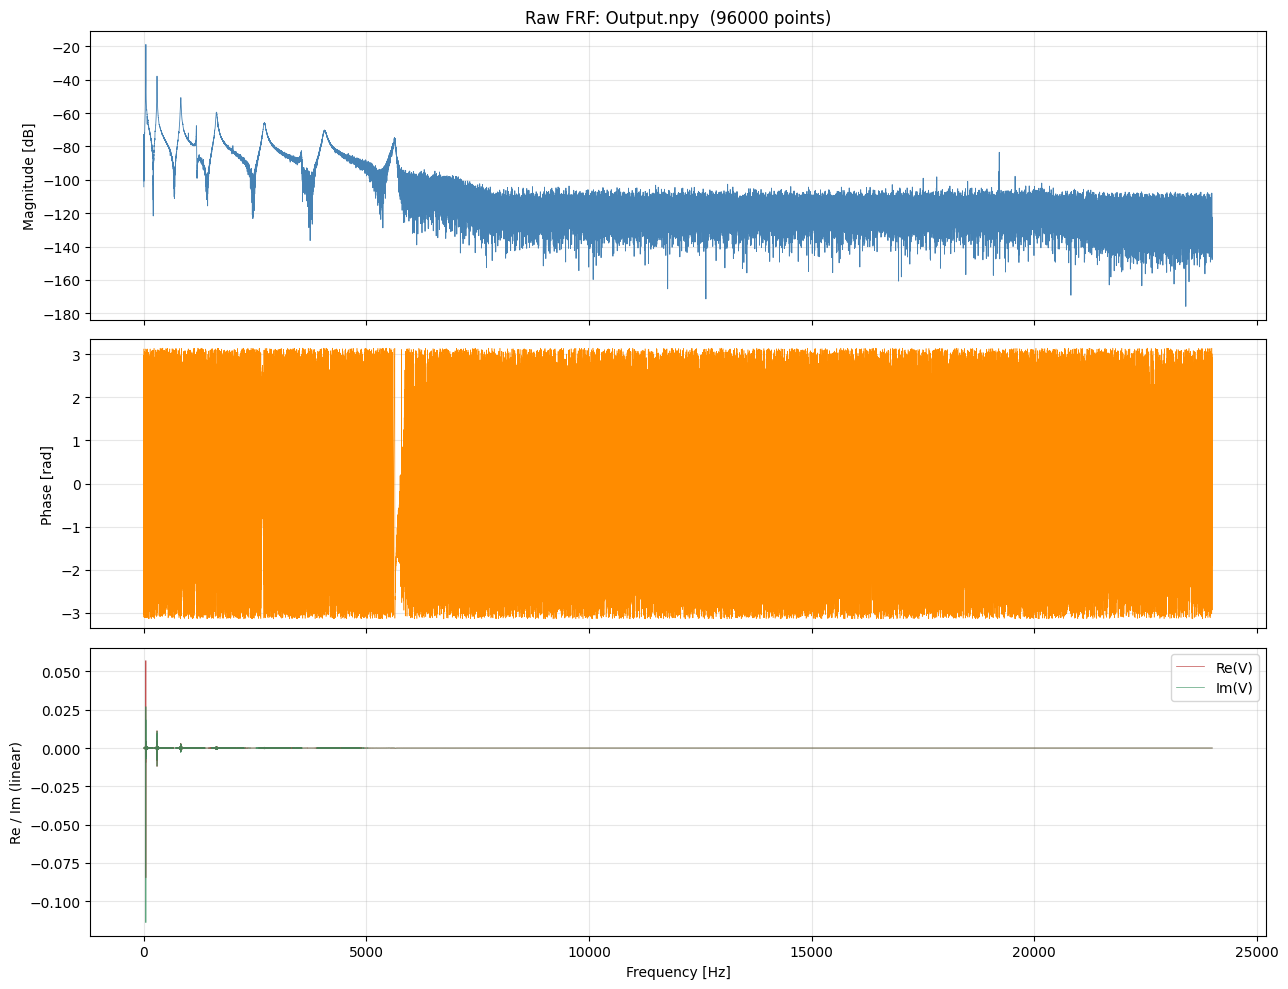

Peak |V|       : 1.146e-01  at 46.00 Hz
Median |V|     : 1.609e-06
Min |V|        : 1.606e-09  at 23404.50 Hz
Dynamic range  : 157.1 dB


In [ ]:
# ── Visualise raw FRF: magnitude (dB) and phase (rad) ─────────────────────────
mag = np.abs(V_arr)
phase = np.angle(V_arr)

fig, axs = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Magnitude in dB — standard FRF view
axs[0].plot(f_arr, 20*np.log10(mag + 1e-30), lw=0.6, color="steelblue")
axs[0].set_ylabel("Magnitude [dB]")
axs[0].set_title(f"Raw FRF: {uploaded_name}  ({N} points)")
axs[0].grid(alpha=0.3)

# Phase (wrapped, raw — this is what you'd actually feed to atan2)
axs[1].plot(f_arr, phase, lw=0.4, color="darkorange")
axs[1].set_ylabel("Phase [rad]")
axs[1].set_ylim(-np.pi - 0.2, np.pi + 0.2)
axs[1].grid(alpha=0.3)

# Real and imaginary parts on linear scale — useful for seeing what the
# PINN data loss actually compares against
axs[2].plot(f_arr, V_arr.real, lw=0.5, label="Re(V)", color="firebrick", alpha=0.8)
axs[2].plot(f_arr, V_arr.imag, lw=0.5, label="Im(V)", color="seagreen",  alpha=0.8)
axs[2].set_ylabel("Re / Im (linear)")
axs[2].set_xlabel("Frequency [Hz]")
axs[2].legend(loc="upper right")
axs[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Quick stats for context
print(f"Peak |V|       : {mag.max():.3e}  at {f_arr[np.argmax(mag)]:.2f} Hz")
print(f"Median |V|     : {np.median(mag):.3e}")
print(f"Min |V|        : {mag.min():.3e}  at {f_arr[np.argmin(mag)]:.2f} Hz")
print(f"Dynamic range  : {20*np.log10(mag.max()/mag.min()):.1f} dB")

## 4. Filter, smooth and subsample the experimental FRF

**Why cut at 5000 Hz?**
Euler-Bernoulli beam theory is only valid for the first few bending modes.
Beyond ~5 kHz for this geometry, the model is inaccurate and the data is noise-dominated.
Training on that region harms parameter identification.

**Why smooth?**
The PINN's physics loss enforces a smooth analytical solution.
Raw experimental noise conflicts with this — the optimizer chases noise instead of physics,
and identified parameters (E(x), eta, etc.) never converge.
Savitzky-Golay preserves resonance peak positions and shapes while removing the noise floor.

**v4 CHANGE — Smooth Re and Im separately:**
v3 smoothed magnitude and phase independently. Phase has wrapping discontinuities
at every resonance, so SG filter flattened phase to ~0, destroying the imaginary
component of the training data. v4 instead smooths Re(V) and Im(V) separately —
both are smooth continuous functions with no wrapping issues, so phase is preserved.

**Why subsample to 300 points?**
You have 5 scalar unknowns + the E(x) function to identify.
300 points spread across 0-5 kHz gives excellent coverage of all resonance peaks.
More points just makes training slower without adding physical information.

NPY keys: ['t', 's1_t', 'freq_s1', 's1_fft']
After cutoff: 19997 points  (1.0 – 5000.0 Hz)
SG window: 15 points  (~3.75 Hz)
Detected 244 peaks at: [44.2, 298.2, 475.2, 669.5, 677.0, 687.2, 693.8, 830.2, 1199.5, 1207.0, 1221.8, 1228.0, 1242.5, 1252.5, 1261.5, 1271.5, 1278.0, 1286.5, 1293.0, 1298.5, 1309.5, 1323.2, 1331.5, 1340.0, 1350.0, 1363.5, 1369.5, 1376.5, 1383.8, 1389.8, 1396.8, 1404.5, 1409.8, 1415.0, 1424.8, 1433.0, 1440.0, 1445.0, 1451.5, 1475.0, 1605.8, 1792.5, 1979.5, 1992.0, 2000.0, 2006.8, 2012.5, 2018.8, 2029.8, 2039.2, 2047.0, 2054.2, 2059.2, 2064.8, 2069.8, 2082.8, 2092.8, 2102.5, 2119.2, 2128.2, 2135.0, 2144.5, 2158.5, 2163.5, 2174.2, 2183.2, 2195.8, 2234.5, 2246.0, 2278.8, 2285.5, 2291.8, 2299.2, 2318.8, 2330.5, 2337.0, 2345.0, 2350.5, 2358.2, 2365.0, 2371.0, 2377.8, 2388.2, 2395.5, 2400.8, 2405.8, 2413.5, 2420.0, 2432.0, 2440.0, 2446.0, 2453.2, 2459.5, 2467.5, 2473.0, 2479.8, 2486.0, 2493.8, 2501.5, 2510.0, 2521.0, 2526.2, 2544.5, 2551.8, 2557.2, 2566.5, 2575.5, 2704.

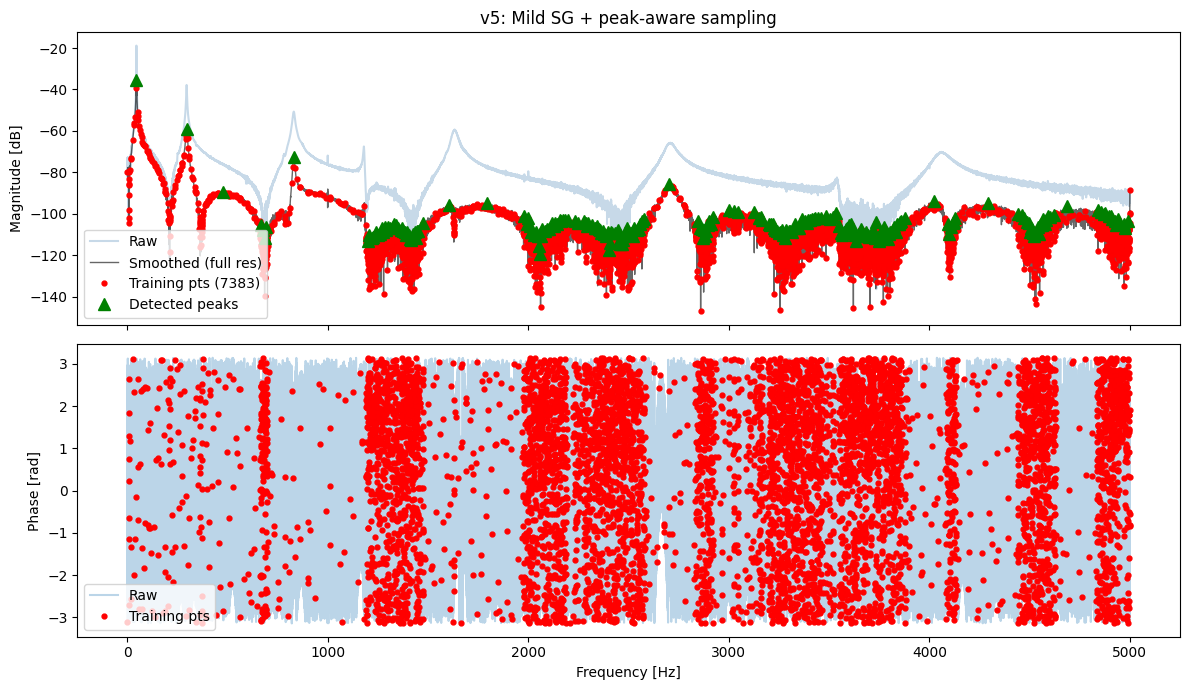


>> CHECK: Red dots should sit ON the peak tops in the magnitude plot.
>>        Density should be high around peaks/anti-resonances, low elsewhere.
>>        If a peak has no red dot near its top, lower `prominence` or raise PTS_PER_PEAK.


In [ ]:
# f_raw, x_raw, V_raw = load_frf(uploaded_name, x_meas=x_meas)

# # ── Hard frequency cutoff ─────────────────────────────────────────────────────
# mask = (f_raw >= MIN_FREQ_HZ) & (f_raw <= MAX_FREQ_HZ)
# f_cut, V_cut = f_raw[mask], V_raw[mask]
# print(f"After cutoff: {len(f_cut)} points  ({f_cut.min():.1f} \u2013 {f_cut.max():.1f} Hz)")

# # ── Savitzky-Golay smoothing on REAL and IMAGINARY parts separately ───────────
# # v3 BUG: smoothing magnitude and phase destroyed the phase information.
# # v4 FIX: smooth Re(V) and Im(V) independently — both are smooth, no wrapping.
# sg_win = min(51, (len(f_cut)//20)*2 + 1)
# sg_win = max(sg_win, 5)

# V_re_smooth = savgol_filter(V_cut.real, window_length=sg_win, polyorder=3)
# V_im_smooth = savgol_filter(V_cut.imag, window_length=sg_win, polyorder=3)
# V_smooth    = V_re_smooth + 1j * V_im_smooth

# print(f"SG window: {sg_win} points")

# # ── Subsample to N_train evenly spaced points ─────────────────────────────────
# N_train = 300
# idx     = np.linspace(0, len(f_cut)-1, N_train, dtype=int)
# f_train = f_cut[idx]
# V_train = V_smooth[idx]
# x_train = np.full_like(f_train, x_meas)
# print(f"Training points: {len(f_train)}")

# # ── Diagnostic plot: raw vs smoothed ─────────────────────────────────────────
# fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
# axs[0].plot(f_cut,   20*np.log10(np.abs(V_cut)   + eps_db), alpha=0.35, label="Raw")
# axs[0].plot(f_train, 20*np.log10(np.abs(V_train)  + eps_db), "r-", lw=1.8, label="Smoothed + subsampled")
# axs[0].set_ylabel("Magnitude [dB]"); axs[0].legend(); axs[0].set_title("Experimental FRF preprocessing (v4: Re/Im smoothing)")
# axs[1].plot(f_cut,   np.angle(V_cut),  alpha=0.35, label="Raw")
# axs[1].plot(f_train, np.angle(V_train), "r-", lw=1.8, label="Smoothed + subsampled")
# axs[1].set_ylabel("Phase [rad]"); axs[1].set_xlabel("Frequency [Hz]"); axs[1].legend()
# plt.tight_layout(); plt.show()

# print("\n>> CHECK: The red phase curve should show clear transitions at resonances,")
# print(">>        NOT a flat line near zero. If it's flat, something is still wrong.")

from scipy.signal import find_peaks, peak_widths

f_raw, x_raw, V_raw = load_frf(uploaded_name, x_meas=x_meas)

# ── Hard frequency cutoff ─────────────────────────────────────────────────────
mask = (f_raw >= MIN_FREQ_HZ) & (f_raw <= MAX_FREQ_HZ)
f_cut, V_cut = f_raw[mask], V_raw[mask]
print(f"After cutoff: {len(f_cut)} points  ({f_cut.min():.1f} \u2013 {f_cut.max():.1f} Hz)")

# ── Mild Savitzky-Golay on Re and Im separately ───────────────────────────────
# v5 CHANGE: window narrowed from ~51 (~8.5 Hz) to ~15 (~2.5 Hz).
# Wide windows flatten narrow resonance peaks; mild smoothing only suppresses
# sample-level jitter and leaves peak structure intact.
sg_win = 15
if sg_win % 2 == 0: sg_win += 1   # SG requires odd window
sg_win = min(sg_win, len(f_cut) - 1 if len(f_cut) % 2 == 0 else len(f_cut))

V_re_smooth = savgol_filter(V_cut.real, window_length=sg_win, polyorder=3)
V_im_smooth = savgol_filter(V_cut.imag, window_length=sg_win, polyorder=3)
V_smooth    = V_re_smooth + 1j * V_im_smooth
print(f"SG window: {sg_win} points  (~{sg_win*(f_cut[1]-f_cut[0]):.2f} Hz)")

# ── Detect peaks on smoothed magnitude ────────────────────────────────────────
mag_db = 20 * np.log10(np.abs(V_smooth) + eps_db)
# `prominence` filters out noise wiggles. 10 dB is a reasonable starting point;
# raise it if spurious peaks are picked up, lower it if true peaks are missed.
peak_idx, peak_props = find_peaks(mag_db, prominence=10.0, distance=20)
peak_freqs = f_cut[peak_idx]
print(f"Detected {len(peak_idx)} peaks at: {np.round(peak_freqs, 1).tolist()} Hz")

# Estimate FWHM in Hz for each peak (rel_height=0.5 gives half-prominence width)
widths_samples, _, _, _ = peak_widths(mag_db, peak_idx, rel_height=0.5)
df_raw = f_cut[1] - f_cut[0]
peak_fwhm_hz = widths_samples * df_raw
# Floor the FWHM so we don't get unreasonably narrow sampling bands from noise
peak_fwhm_hz = np.maximum(peak_fwhm_hz, 0.5)
print(f"Estimated FWHMs (Hz): {np.round(peak_fwhm_hz, 2).tolist()}")

# ── Build peak-aware training set ─────────────────────────────────────────────
PTS_PER_PEAK       = 50          # points within ±5*FWHM of each peak
PTS_PER_ANTIRES    = 8           # points across each anti-resonance dip
PTS_BACKGROUND     = 100         # sparse coverage everywhere else
PEAK_BAND_FWHMS    = 5.0         # half-width of the dense band, in FWHMs

f_train_list = []

# (1) Dense around each peak
for fp, fwhm in zip(peak_freqs, peak_fwhm_hz):
    band_lo = max(fp - PEAK_BAND_FWHMS * fwhm, f_cut[0])
    band_hi = min(fp + PEAK_BAND_FWHMS * fwhm, f_cut[-1])
    f_train_list.append(np.linspace(band_lo, band_hi, PTS_PER_PEAK))

# (2) Anti-resonance dips: detect by inverting magnitude and running find_peaks
antires_idx, _ = find_peaks(-mag_db, prominence=10.0, distance=20)
antires_freqs  = f_cut[antires_idx]
print(f"Detected {len(antires_idx)} anti-resonances at: {np.round(antires_freqs, 1).tolist()} Hz")
for fa in antires_freqs:
    # Use ±2 Hz band around each dip (anti-resonances are usually narrower than peaks)
    band_lo = max(fa - 2.0, f_cut[0])
    band_hi = min(fa + 2.0, f_cut[-1])
    f_train_list.append(np.linspace(band_lo, band_hi, PTS_PER_ANTIRES))

# (3) Sparse background (uniform across full range)
f_train_list.append(np.linspace(f_cut[0], f_cut[-1], PTS_BACKGROUND))

# Merge, deduplicate, and sort
f_train = np.unique(np.concatenate(f_train_list))
# Snap each requested freq to the nearest available raw frequency
snap_idx = np.searchsorted(f_cut, f_train)
snap_idx = np.clip(snap_idx, 0, len(f_cut) - 1)
# Resolve edges: pick whichever neighbour is closer
left  = np.clip(snap_idx - 1, 0, len(f_cut) - 1)
right = snap_idx
choose_left = np.abs(f_cut[left] - f_train) < np.abs(f_cut[right] - f_train)
snap_idx = np.where(choose_left, left, right)
snap_idx = np.unique(snap_idx)

f_train = f_cut[snap_idx]
V_train = V_smooth[snap_idx]
x_train = np.full_like(f_train, x_meas)
print(f"Training points: {len(f_train)}")

# ── Diagnostic plot ───────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axs[0].plot(f_cut, 20*np.log10(np.abs(V_cut) + eps_db),
            alpha=0.30, label="Raw", color="steelblue")
axs[0].plot(f_cut, mag_db, "-", lw=1.0, color="black", alpha=0.6,
            label="Smoothed (full res)")
axs[0].plot(f_train, 20*np.log10(np.abs(V_train) + eps_db),
            "ro", ms=3.5, label=f"Training pts ({len(f_train)})")
axs[0].plot(peak_freqs, mag_db[peak_idx], "g^", ms=9, label="Detected peaks")
axs[0].set_ylabel("Magnitude [dB]"); axs[0].legend(loc="lower left")
axs[0].set_title("v5: Mild SG + peak-aware sampling")

axs[1].plot(f_cut,   np.angle(V_cut),    alpha=0.30, label="Raw")
axs[1].plot(f_train, np.angle(V_train), "ro", ms=3.5, label="Training pts")
axs[1].set_ylabel("Phase [rad]"); axs[1].set_xlabel("Frequency [Hz]")
axs[1].legend(loc="lower left")
plt.tight_layout(); plt.show()

print("\n>> CHECK: Red dots should sit ON the peak tops in the magnitude plot.")
print(">>        Density should be high around peaks/anti-resonances, low elsewhere.")
print(">>        If a peak has no red dot near its top, lower `prominence` or raise PTS_PER_PEAK.")

## 5. Convert to tensors and define normalization

Neural networks train faster when inputs are scaled to [-1, 1].
Without normalization, ω spans ~6 to ~31,000 rad/s — the gradient signal
for low-frequency inputs would be negligible compared to high-frequency ones.


In [ ]:
omega_train  = 2.0 * np.pi * f_train

x_t     = torch.tensor(x_train,       dtype=DTYPE, device=device).view(-1,1)
omega_t = torch.tensor(omega_train,   dtype=DTYPE, device=device).view(-1,1)
Vr_t    = torch.tensor(V_train.real,  dtype=DTYPE, device=device).view(-1,1)
Vi_t    = torch.tensor(V_train.imag,  dtype=DTYPE, device=device).view(-1,1)

omega_min = float(omega_train.min())
omega_max = float(omega_train.max())

def norm_x(x):
    return 2.0 * x / L - 1.0                                   # [0,L]   → [-1,1]

def norm_omega(w):
    return 2.0*(w - omega_min)/(omega_max - omega_min) - 1.0   # [wmin,wmax] → [-1,1]

print(f"omega range: {omega_min:.1f} – {omega_max:.1f} rad/s")


## 6. Neural network architectures

**Two networks are trained simultaneously:**

`WNet` — displacement field network
- Input: (x, omega), Output: (W_real, W_imag)
- Represents the complex displacement solution at any spatial point and frequency.

`ENet` — spatially varying stiffness network
- Input: (x), Output: E(x) bounded in [E_MIN, E_MAX]
- Learns how Young's modulus varies along the beam length.

**v4 CHANGE — Sigmoid bounding for E(x):**
v3 used softplus (unbounded above), and E(x) blew up to 4400 GPa.
v4 uses sigmoid reparameterization: `E(x) = E_min + (E_max - E_min) * sigmoid(raw)`
This guarantees E(x) stays in [50, 400] GPa — physically plausible for metals.
The last layer bias is initialized so the network starts at ~E0_init.

Both use **Tanh activations** — required for PINNs because we compute up to 4th-order
spatial derivatives via autograd. ReLU has zero 2nd derivative almost everywhere
and would make the physics loss identically zero.

In [ ]:
# ── E(x) bounds [Pa] ─────────────────────────────────────────────────────────
E_MIN = 50e9    # 50 GPa  — softest plausible metal
E_MAX = 400e9   # 400 GPa — hardest plausible metal/ceramic


class WNet(nn.Module):
    """Displacement field: (x, omega) -> (W_real, W_imag)"""
    def __init__(self, hidden=[2,128,128,128,128,2]):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden[i], hidden[i+1])
                                     for i in range(len(hidden)-1)])
        self.act = nn.Tanh()

    def forward(self, x, omega):
        z = torch.cat([norm_x(x), norm_omega(omega)], dim=1)
        for layer in self.layers[:-1]:
            z = self.act(layer(z))
        out = self.layers[-1](z)
        return out[:,0:1], out[:,1:2]   # Wr, Wi


class ENet(nn.Module):
    """
    Spatially varying Young's modulus: x -> E(x) in [E_MIN, E_MAX]
    v4 CHANGE: sigmoid bounding instead of softplus (which was unbounded).
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

        # Initialize last layer so sigmoid output ≈ E0_init
        with torch.no_grad():
            target_sigmoid = (E0_init - E_MIN) / (E_MAX - E_MIN)
            init_bias = np.log(target_sigmoid / (1.0 - target_sigmoid))
            self.net[-1].bias.fill_(init_bias)
            self.net[-1].weight.fill_(0.0)

    def forward(self, x):
        xn  = norm_x(x)
        raw = self.net(xn)
        return E_MIN + (E_MAX - E_MIN) * torch.sigmoid(raw)


w_net = WNet().to(device).to(DTYPE)
e_net = ENet().to(device).to(DTYPE)

print("WNet params:", sum(p.numel() for p in w_net.parameters()))
print("ENet params:", sum(p.numel() for p in e_net.parameters()))

## 7. Scalar trainable parameters

`eta`, `kx`, `kphi`, `F` are identified as scalar `nn.Parameter` objects.
All use softplus to enforce positivity.

Note: `E(x)` is now handled by ENet above, not a scalar.
The scalar parameters capture damping, boundary compliance, and excitation force.


In [ ]:
def inv_sp(y):
    y = np.float64(y)
    return float(np.where(y > 50, y, np.log(np.expm1(y))))

eta_scale  = 1.0
kx_scale   = 1e3      # N/m   — start soft, let optimizer find the right level
kphi_scale = 1e1      # N*m/rad
F_scale    = 1.0      # N

eta_raw  = nn.Parameter(torch.tensor([inv_sp(eta_init/eta_scale)],   dtype=DTYPE, device=device))
kx_raw   = nn.Parameter(torch.tensor([inv_sp(kx_init/kx_scale)],     dtype=DTYPE, device=device))
kphi_raw = nn.Parameter(torch.tensor([inv_sp(kphi_init/kphi_scale)], dtype=DTYPE, device=device))
F_raw    = nn.Parameter(torch.tensor([inv_sp(F_init/F_scale)],       dtype=DTYPE, device=device))

def get_params():
    sp = torch.nn.functional.softplus
    return (
        (sp(eta_raw)  + 1e-12) * eta_scale,
        (sp(kx_raw)   + 1e-12) * kx_scale,
        (sp(kphi_raw) + 1e-12) * kphi_scale,
        (sp(F_raw)    + 1e-12) * F_scale,
    )

# v4 CHANGE: scalar params LR raised to 1e-3 (was 5e-4 in v3 — kx was stuck)
optimizer = torch.optim.Adam([
    {"params": list(w_net.parameters()),                           "lr": 1e-3},
    {"params": list(e_net.parameters()),                           "lr": 1e-3},
    {"params": [eta_raw, kx_raw, kphi_raw, F_raw],                "lr": 1e-3},
])

# v4 CHANGE: CosineAnnealingWarmRestarts instead of ReduceLROnPlateau
# Eliminates the periodic loss spikes seen in v3.
# T_0=4000 means first restart after 4000 epochs, T_mult=2 doubles each cycle.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=4000, T_mult=2, eta_min=1e-6
)

print("eta_init :", eta_init)
print("kx_init  :", kx_init)
print("kphi_init:", kphi_init)
print("F_init   :", F_init)

## 8. Collocation points for PDE residual

Collocation points are (x, ω) locations where we evaluate the beam PDE.
They are **separate from the data points** — they enforce the physics equation
everywhere in the (x, ω) domain, not just where measurements exist.

`x_col` requires `requires_grad=True` because we differentiate W and E
up to 4th order with respect to x.


In [ ]:
Nx, Nw = 50, 50   # 2500 collocation points total

xc = torch.linspace(0.0, L, Nx, dtype=DTYPE, device=device)
wc = torch.linspace(omega_min, omega_max, Nw, dtype=DTYPE, device=device)

xx, ww    = torch.meshgrid(xc, wc, indexing="ij")
x_col     = xx.reshape(-1,1).clone().detach().requires_grad_(True)
omega_col = ww.reshape(-1,1).clone().detach()

print(f"Collocation grid: {Nx}×{Nw} = {x_col.shape[0]} points")


## 9. Autograd derivative helper

`grad(y, x)` computes ∂y/∂x using PyTorch autograd.
We call this sequentially to get higher-order derivatives:
`W_x → W_xx → W_xxx → W_xxxx` and `E_x → E_xx`.

`create_graph=True` is essential — it keeps the computational graph alive
so that gradients of gradients can themselves be differentiated during backprop.


In [ ]:
def grad(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


## 10. Physics-informed loss function

### PDE for spatially varying E(x)

For constant E, the beam PDE is simply: `EI·W'''' - ρAω²W = 0`

For **spatially varying E(x)**, the bending moment is `M = E(x)I·W''`, and the
PDE becomes (applying the product rule twice):

```
d²/dx²[E(x)I·W''(x)] - ρAω²W(x) = 0

Expanding:
E(x)·W'''' + 2·E'(x)·W''' + E''(x)·W'' - (ρA/I)·ω²·W = 0
```

With complex modulus E*(x) = E(x)(1+jη), the real and imaginary residuals are:

```
r_real = I·[E·Wr'''' + 2E'·Wr''' + E''·Wr'' - η(E·Wi'''' + 2E'·Wi''' + E''·Wi'')] - ρAω²Wr
r_imag = I·[E·Wi'''' + 2E'·Wi''' + E''·Wi'' + η(E·Wr'''' + 2E'·Wr''' + E''·Wr'')] - ρAω²Wi
```

### Boundary conditions (fixed x=0, free x=L)

**At x=0 (clamped with spring compliance):**
- `E(0)I·W''(0) + kphi·W'(0) = 0`   ← rotational spring
- `E(0)I·W'''(0) + kx·W(0) = 0`     ← translational spring

**At x=L (free end with tip mass and force):**
- `E(L)I·W''(L) = 0`                         ← zero moment at free tip
- `E(L)I·W'''(L) + m_tip·ω²·W(L) + F = 0`  ← tip mass inertia + applied force

### Data loss
Measured FRF is velocity: `V = iω·W`
So: `V_real = -ω·W_imag`,  `V_imag = +ω·W_real`

### Loss weights
- `w_pde = 10`  — physics dominates
- `w_bc  = 100` — BCs are exact constraints, highest priority
- `w_data = 1`  — data is trusted but smoothed/noisy


In [ ]:
A_t     = torch.tensor(A,     dtype=DTYPE, device=device)
I_t     = torch.tensor(I,     dtype=DTYPE, device=device)
rho_t   = torch.tensor(rho,   dtype=DTYPE, device=device)
m_tip_t = torch.tensor(m_tip, dtype=DTYPE, device=device)


def pinn_loss(w_pde=10.0, w_bc=100.0, w_data=1.0):
    eta, kx, kphi, F = get_params()

    # ── Spatially varying E(x) and its derivatives at collocation points ─────
    # E'(x) and E''(x) come automatically from autograd through e_net
    E_col  = e_net(x_col)                # shape (Nx*Nw, 1)
    E_x    = grad(E_col, x_col)
    E_xx   = grad(E_x,   x_col)

    # ── Displacement field and derivatives ───────────────────────────────────
    Wr, Wi   = w_net(x_col, omega_col)
    Wr_x     = grad(Wr, x_col);   Wi_x     = grad(Wi, x_col)
    Wr_xx    = grad(Wr_x, x_col); Wi_xx    = grad(Wi_x, x_col)
    Wr_xxx   = grad(Wr_xx,x_col); Wi_xxx   = grad(Wi_xx,x_col)
    Wr_xxxx  = grad(Wr_xxx,x_col);Wi_xxxx  = grad(Wi_xxx,x_col)

    omega2 = omega_col**2

    # ── PDE residual for variable E(x) ───────────────────────────────────────
    # Real part: I*[E*Wr'''' + 2E'*Wr''' + E''*Wr'' - eta*(E*Wi'''' + 2E'*Wi''' + E''*Wi'')] - rho*A*omega^2*Wr
    LWr = E_col*Wr_xxxx + 2*E_x*Wr_xxx + E_xx*Wr_xx   # L[Wr] = d²/dx²(E*W'')
    LWi = E_col*Wi_xxxx + 2*E_x*Wi_xxx + E_xx*Wi_xx   # L[Wi]

    r_pde_r = I_t*(LWr - eta*LWi) - rho_t*A_t*omega2*Wr
    r_pde_i = I_t*(LWi + eta*LWr) - rho_t*A_t*omega2*Wi
    pde_loss = torch.mean(r_pde_r**2 + r_pde_i**2)

    # ── Boundary conditions ───────────────────────────────────────────────────
    omega_b = omega_col.detach()

    # x = 0 (fixed end with spring compliance)
    x0         = torch.zeros_like(omega_b, requires_grad=True)
    Wr0, Wi0   = w_net(x0, omega_b)
    E0_val     = e_net(x0)
    Wr0_x      = grad(Wr0, x0);   Wi0_x  = grad(Wi0, x0)
    Wr0_xx     = grad(Wr0_x, x0); Wi0_xx = grad(Wi0_x, x0)
    Wr0_xxx    = grad(Wr0_xx,x0); Wi0_xxx= grad(Wi0_xx,x0)

    EI0_r = E0_val * I_t          # real part of EI at x=0
    EI0_i = E0_val * I_t * eta    # imaginary part

    # Rotational spring: EI*W''(0) + kphi*W'(0) = 0
    bc0_rot_r = (EI0_r*Wr0_xx - EI0_i*Wi0_xx) + kphi*Wr0_x
    bc0_rot_i = (EI0_r*Wi0_xx + EI0_i*Wr0_xx) + kphi*Wi0_x
    # Translational spring: EI*W'''(0) + kx*W(0) = 0
    bc0_tr_r  = (EI0_r*Wr0_xxx - EI0_i*Wi0_xxx) + kx*Wr0
    bc0_tr_i  = (EI0_r*Wi0_xxx + EI0_i*Wr0_xxx) + kx*Wi0

    # x = L (free end with tip mass and force)
    xL         = torch.full_like(omega_b, L, requires_grad=True)
    WrL, WiL   = w_net(xL, omega_b)
    E_L_val    = e_net(xL)
    WrL_x      = grad(WrL, xL);    WiL_x   = grad(WiL, xL)
    WrL_xx     = grad(WrL_x, xL);  WiL_xx  = grad(WiL_x, xL)
    WrL_xxx    = grad(WrL_xx, xL); WiL_xxx = grad(WiL_xx, xL)

    EIL_r = E_L_val * I_t
    EIL_i = E_L_val * I_t * eta

    # Zero moment at free tip: EI(L)*W''(L) = 0
    bcL_m_r = EIL_r*WrL_xx - EIL_i*WiL_xx
    bcL_m_i = EIL_r*WiL_xx + EIL_i*WrL_xx
    # Tip mass + force: EI(L)*W'''(L) + m_tip*omega^2*W(L) + F = 0
    bcL_v_r = (EIL_r*WrL_xxx - EIL_i*WiL_xxx) + m_tip_t*omega_b**2*WrL + F
    bcL_v_i = (EIL_r*WiL_xxx + EIL_i*WrL_xxx) + m_tip_t*omega_b**2*WiL

    bc_loss = torch.mean(
        bc0_rot_r**2 + bc0_rot_i**2 +
        bc0_tr_r**2  + bc0_tr_i**2  +
        bcL_m_r**2   + bcL_m_i**2   +
        bcL_v_r**2   + bcL_v_i**2
    )

    # ── Data loss: V = i*omega*W → Vr=-omega*Wi, Vi=+omega*Wr ───────────────
    Wr_d, Wi_d = w_net(x_t, omega_t)
    Vp_r = -omega_t * Wi_d
    Vp_i =  omega_t * Wr_d
    data_loss = torch.mean((Vp_r - Vr_t)**2 + (Vp_i - Vi_t)**2)

    total = w_pde*pde_loss + w_bc*bc_loss + w_data*data_loss

    return total, {
        "loss": total.item(), "pde": pde_loss.item(),
        "bc": bc_loss.item(), "data": data_loss.item(),
        "eta": eta.item(), "kx": kx.item(),
        "kphi": kphi.item(), "F": F.item(),
    }


## 11. Training — Phase 1: Adam

**Strategy:** Two-phase training.
- Phase 1 (this cell): Adam optimizer, 20,000 epochs. Makes rapid initial progress,
  explores the loss landscape broadly.
- Phase 2 (next cell): L-BFGS, 300 steps. Converges precisely near the solution.
  L-BFGS uses curvature information — far more efficient than Adam near a minimum.

**Loss weights:** `w_pde=10, w_bc=100, w_data=1`
Physics and BCs dominate. Data is trusted but smoothed — we weight it lower
so the optimizer does not chase residual noise.

**What to watch in the printout:**
- All three loss terms should decrease
- `eta` should converge to a stable value (typically 0.001–0.05 for metals)
- `kx` and `kphi` converge to values indicating boundary compliance
- If `data` loss stays very high while `pde` drops, the physics model may not
  fit your beam well — check material and geometry settings


In [ ]:
EPOCHS_ADAM = 20000
W_PDE, W_BC, W_DATA = 10.0, 100.0, 1.0

# ── Dict of physical params for checkpoint save/load ─────────────────────────
phys_params = {"eta_raw": eta_raw, "kx_raw": kx_raw,
               "kphi_raw": kphi_raw, "F_raw": F_raw}

# ── Try to resume from a previous Adam checkpoint ────────────────────────────
start_epoch, saved_history = load_adam_checkpoint(
    w_net, e_net, phys_params, optimizer, scheduler)

if saved_history is not None:
    history = saved_history
else:
    history = {k:[] for k in ["loss","pde","bc","data","eta","kx","kphi","F"]}

for epoch in range(start_epoch, EPOCHS_ADAM):
    optimizer.zero_grad()
    loss, logs = pinn_loss(W_PDE, W_BC, W_DATA)
    loss.backward()
    optimizer.step()
    scheduler.step()    # v4: no argument (CosineAnnealing doesn't take loss)

    for k in history: history[k].append(logs[k])

    if epoch % 1000 == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Ep {epoch:6d} | Loss {logs['loss']:.3e} | PDE {logs['pde']:.3e} | "
              f"BC {logs['bc']:.3e} | Data {logs['data']:.3e} | "
              f"eta {logs['eta']:.5f} | kx {logs['kx']:.3e} | "
              f"kphi {logs['kphi']:.3e} | F {logs['F']:.4f} | lr {lr:.1e}")

    # ── Checkpoint to Drive ──────────────────────────────────────────────────
    if epoch % ADAM_CKPT_EVERY == 0 or epoch == EPOCHS_ADAM - 1:
        save_adam_checkpoint(epoch, w_net, e_net, phys_params,
                            optimizer, scheduler, history)

print("\nAdam phase complete.")

## 12. Training — Phase 2: L-BFGS refinement

L-BFGS is a quasi-Newton method that uses an approximation of the inverse Hessian
to take much more informed steps than Adam's gradient descent.
Near a solution it converges in far fewer iterations — each "step" internally
performs up to 50 line-search iterations with the strong Wolfe condition.

**Important:** L-BFGS requires a `closure()` function that recomputes the loss
and calls `.backward()` each time it is called internally. This is standard PyTorch usage.


In [ ]:
print("Starting L-BFGS refinement...")

all_params = (list(w_net.parameters()) + list(e_net.parameters()) +
              [eta_raw, kx_raw, kphi_raw, F_raw])

opt_lbfgs = torch.optim.LBFGS(
    all_params, lr=0.1, max_iter=20,     # v4: reduced from 50 — faster per step
    history_size=50, line_search_fn="strong_wolfe"
)

LBFGS_STEPS = 300

# ── Try to resume from a previous L-BFGS checkpoint ─────────────────────────
start_step = load_lbfgs_checkpoint(w_net, e_net, phys_params, opt_lbfgs)

for step in range(start_step, LBFGS_STEPS):
    def closure():
        opt_lbfgs.zero_grad()
        loss, _ = pinn_loss(W_PDE, W_BC, W_DATA)
        loss.backward()
        return loss

    opt_lbfgs.step(closure)

    if step % 10 == 0:     # v4: print every 10 instead of every 30
        _, logs = pinn_loss(W_PDE, W_BC, W_DATA)
        eta_v, kx_v, kphi_v, F_v = get_params()
        print(f"L-BFGS {step:4d} | Loss {logs['loss']:.3e} | PDE {logs['pde']:.3e} | "
              f"Data {logs['data']:.3e} | eta {eta_v.item():.5f} | "
              f"kx {kx_v.item():.3e} | kphi {kphi_v.item():.3e} | F {F_v.item():.4f}")

    # ── Checkpoint to Drive ──────────────────────────────────────────────────
    if step % LBFGS_CKPT_EVERY == 0 or step == LBFGS_STEPS - 1:
        save_lbfgs_checkpoint(step, w_net, e_net, phys_params, opt_lbfgs)

print("\nL-BFGS phase complete.")

## 13. Training history

All three loss components should decrease and plateau.

- If **pde stays high**: the network has not learned the beam equation well —
  try more collocation points or more epochs.
- If **data stays high while pde is low**: the physics model may not match
  your experiment — check E0_init, geometry, or boundary condition setup.
- If **bc stays high**: boundary conditions are not satisfied — usually a sign
  of wrong BC formulation or too-small w_bc weight.


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].semilogy(history["loss"],  label="total")
axs[0].semilogy(history["pde"],   label="pde")
axs[0].semilogy(history["bc"],    label="bc")
axs[0].semilogy(history["data"],  label="data")
axs[0].legend(); axs[0].set_title("Loss history (Adam phase)"); axs[0].set_xlabel("Epoch")

axs[1].plot(history["eta"],  label="eta")
axs[1].plot(history["kx"],   label="kx (scaled)")
axs[1].plot(history["kphi"], label="kphi (scaled)")
axs[1].plot(history["F"],    label="F")
axs[1].legend(); axs[1].set_title("Scalar parameter convergence"); axs[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


## 14. Identified E(x) spatial profile

This is the key result — the spatially varying Young's modulus profile along the beam.
If E(x) is nearly flat, the beam has uniform stiffness.
Spatial variation indicates non-uniform material, damage, or geometric effects.

**v4 note:** E(x) is now bounded in [50, 400] GPa via sigmoid reparameterization.
In v3, E(x) blew up to 4400 GPa — clearly unphysical. The bounds prevent this.

**Sanity check:** E(x) values should be physically plausible for your material:
- Steel: 180-210 GPa
- Aluminium: 65-75 GPa
- Brass: 95-110 GPa

In [ ]:
w_net.eval(); e_net.eval()

x_plot = np.linspace(0, L, 200)
x_plot_t = torch.tensor(x_plot, dtype=DTYPE, device=device).view(-1,1)

with torch.no_grad():
    E_profile = e_net(x_plot_t).cpu().numpy().reshape(-1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot*1000, E_profile/1e9, "b-", lw=2)
ax.set_xlabel("Position along beam x [mm]")
ax.set_ylabel("E(x) [GPa]")
ax.set_title("Identified spatially varying Young's modulus E(x)")
ax.axhline(E0_init/1e9, color="r", linestyle="--", alpha=0.5, label=f"Initial guess {E0_init/1e9:.0f} GPa")
ax.axhline(E_MIN/1e9, color="gray", linestyle=":", alpha=0.3, label=f"Bounds [{E_MIN/1e9:.0f}, {E_MAX/1e9:.0f}] GPa")
ax.axhline(E_MAX/1e9, color="gray", linestyle=":", alpha=0.3)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"E(x) range: {E_profile.min()/1e9:.2f} - {E_profile.max()/1e9:.2f} GPa")
print(f"E(x) mean:  {E_profile.mean()/1e9:.2f} GPa")

## 15. Final identified scalar parameters


In [ ]:
eta_f, kx_f, kphi_f, F_f = get_params()

print("=== IDENTIFIED SCALAR PARAMETERS ===")
print(f"eta   = {eta_f.item():.6f}        (damping loss factor)")
print(f"kx    = {kx_f.item():.4e} N/m    (translational spring at x=0)")
print(f"kphi  = {kphi_f.item():.4e} N·m/rad (rotational spring at x=0)")
print(f"F     = {F_f.item():.6f} N       (tip force amplitude)")


## 16. PINN prediction vs experimental FRF

This is the final validation. The PINN-predicted velocity FRF should:
- Match the resonance peak **positions** closely (driven by E(x) and geometry)
- Match the peak **heights** approximately (driven by eta and F)
- Produce a smooth curve — it will not reproduce noise between peaks, and should not

If the peaks are misaligned in frequency: E(x) mean level needs adjustment (check E0_init)
If peaks are there but wrong height: check eta and F convergence
If the prediction is still a flat line: check loss history — training may not have converged


In [ ]:
omega_eval_t = omega_t.clone()
x_eval_t     = torch.full_like(omega_eval_t, x_meas, dtype=DTYPE)

with torch.no_grad():
    Wr_p, Wi_p = w_net(x_eval_t, omega_eval_t)
    Vp_r = (-omega_eval_t * Wi_p).cpu().numpy().reshape(-1)
    Vp_i = ( omega_eval_t * Wr_p).cpu().numpy().reshape(-1)
    V_pred = Vp_r + 1j*Vp_i

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(f_train, 20*np.log10(np.abs(V_train) + eps_db),
            alpha=0.5, label="Experimental (smoothed)")
axs[0].plot(f_train, 20*np.log10(np.abs(V_pred)  + eps_db),
            "r--", lw=2, label="PINN prediction")
axs[0].set_ylabel("Magnitude [dB]"); axs[0].legend()
axs[0].set_title("PINN vs Experimental FRF")

axs[1].plot(f_train, np.unwrap(np.angle(V_train)), alpha=0.5, label="Experimental (smoothed)")
axs[1].plot(f_train, np.unwrap(np.angle(V_pred)),  "r--", lw=2, label="PINN prediction")
axs[1].set_ylabel("Phase [rad]"); axs[1].set_xlabel("Frequency [Hz]"); axs[1].legend()

plt.tight_layout(); plt.show()


## 17. Save results


In [ ]:
results = {
    "eta":   float(eta_f.item()),
    "kx":    float(kx_f.item()),
    "kphi":  float(kphi_f.item()),
    "F":     float(F_f.item()),
    "E_profile_x_mm":  (x_plot*1000).tolist(),
    "E_profile_GPa":   (E_profile/1e9).tolist(),
    "geometry": {"L":L,"width":width,"height":height,"rho":rho,"m_tip":m_tip},
    "freq_range_hz": [MIN_FREQ_HZ, MAX_FREQ_HZ],
}
with open("pinn_results.json","w") as f:
    json.dump(results, f, indent=2)

pd.DataFrame({
    "f_hz":        f_train,
    "V_exp_real":  V_train.real,
    "V_exp_imag":  V_train.imag,
    "V_pred_real": V_pred.real,
    "V_pred_imag": V_pred.imag,
    "V_exp_dB":    20*np.log10(np.abs(V_train)+eps_db),
    "V_pred_dB":   20*np.log10(np.abs(V_pred) +eps_db),
}).to_csv("pinn_frf_comparison.csv", index=False)

print("Saved: pinn_results.json")
print("Saved: pinn_frf_comparison.csv")

# ── Save final trained state & clean up per-phase checkpoints ────────────────
# This saves the fully trained model so you can reload it later for inference
# without retraining. The per-phase checkpoints are removed since training
# is complete — they were only needed for crash recovery.
torch.save({
    "w_net": w_net.state_dict(),
    "e_net": e_net.state_dict(),
    "phys":  {k: v.detach().clone() for k, v in phys_params.items()},
    "history": history,
}, CKPT_DONE)

# Remove intermediate checkpoints (no longer needed)
for p in [CKPT_ADAM, CKPT_LBFGS]:
    if os.path.exists(p):
        os.remove(p)

print(f"Saved final model: {CKPT_DONE}")
print("Intermediate checkpoints cleaned up.")


## 18. Utilities: fresh start / reload trained model

**To start a completely fresh training run** (e.g. new experiment file),
delete the checkpoint files first:

```python
import os
for f in [CKPT_ADAM, CKPT_LBFGS, CKPT_DONE]:
    if os.path.exists(f): os.remove(f)
print("Checkpoints cleared — next run will train from scratch.")
```

**To reload a trained model without retraining** (e.g. to make new plots):

```python
ckpt = torch.load(CKPT_DONE, map_location=device, weights_only=False)
w_net.load_state_dict(ckpt["w_net"])
e_net.load_state_dict(ckpt["e_net"])
for k, v in ckpt["phys"].items():
    phys_params[k].data.copy_(v)
print("Loaded trained model from", CKPT_DONE)
```
